In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('Desktop/student_performance_data.csv')
df.head()


,Study_Hours,Attendance,Past_Failures,Parent_Support,Passed
0,10.6,84.9,0,2,0
1,23.9,76.8,0,2,1
2,18.8,65.5,1,1,0
3,15.8,90.7,1,1,0
4,5.6,84.2,1,2,0


In [3]:
X = df[['Study_Hours', 'Attendance', 'Past_Failures', 'Parent_Support']]
y = df['Passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
model_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
model_3.fit(X_train, y_train)

pred_3 = model_3.predict(X_test)
acc_3 = accuracy_score(y_test, pred_3)

print("Accuracy for Depth 3:", acc_3)
print(classification_report(y_test, pred_3))


Accuracy for Depth 3: 0.72
              precision    recall  f1-score   support

           0       0.68      0.62      0.65        42
           1       0.74      0.79      0.77        58

    accuracy                           0.72       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.72      0.72      0.72       100



In [5]:
model_4 = DecisionTreeClassifier(max_depth=4, random_state=42)
model_4.fit(X_train, y_train)

pred_4 = model_4.predict(X_test)
acc_4 = accuracy_score(y_test, pred_4)

print("Accuracy for Depth 4:", acc_4)
print(classification_report(y_test, pred_4))


Accuracy for Depth 4: 0.68
              precision    recall  f1-score   support

           0       0.69      0.43      0.53        42
           1       0.68      0.86      0.76        58

    accuracy                           0.68       100
   macro avg       0.68      0.65      0.64       100
weighted avg       0.68      0.68      0.66       100



In [6]:
model_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_5.fit(X_train, y_train)

pred_5 = model_5.predict(X_test)
acc_5 = accuracy_score(y_test, pred_5)

print("Accuracy for Depth 5:", acc_5)
print(classification_report(y_test, pred_5))


Accuracy for Depth 5: 0.77
              precision    recall  f1-score   support

           0       0.85      0.55      0.67        42
           1       0.74      0.93      0.82        58

    accuracy                           0.77       100
   macro avg       0.80      0.74      0.75       100
weighted avg       0.79      0.77      0.76       100



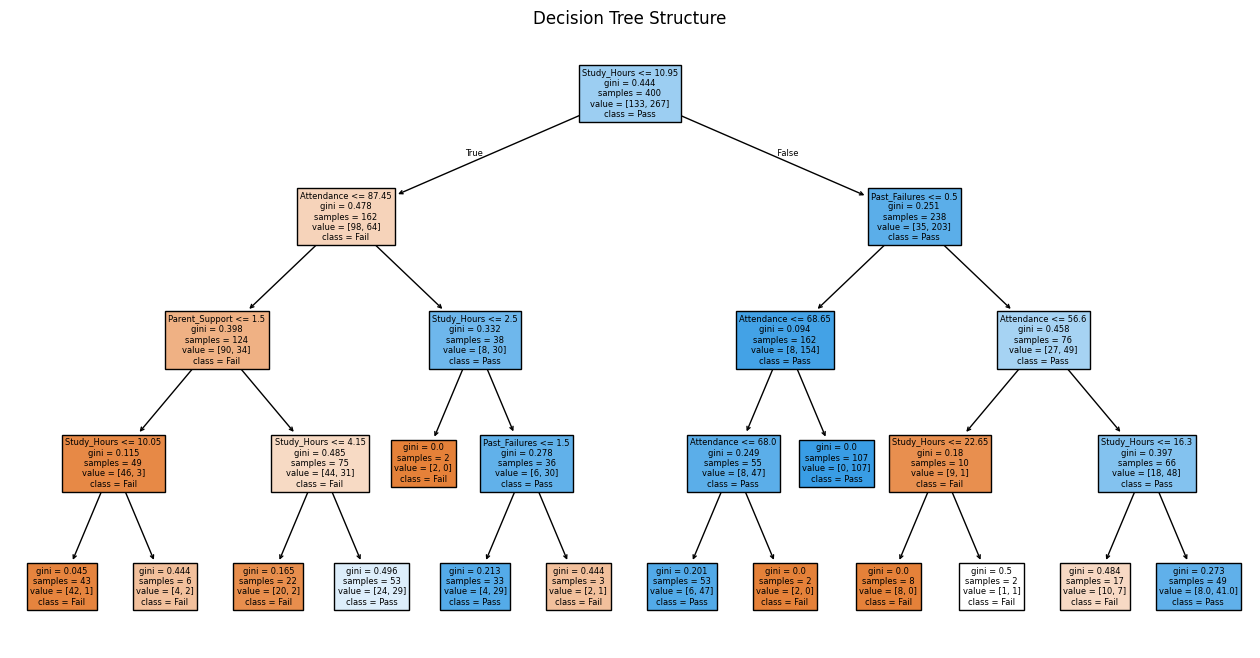

In [8]:
plt.figure(figsize=(16, 8))
plot_tree(model_4, feature_names=list(X.columns), class_names=['Fail', 'Pass'], filled=True)
plt.title("Decision Tree Structure")
plt.show()


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
samples = 200

operating_temp = np.random.uniform(25, 85, samples)
leakage_current = 0.15 * operating_temp + np.random.normal(0, 1.2, samples)

df = pd.DataFrame({'Temperature_C': operating_temp, 'Leakage_Current_mA': leakage_current})
df.head()


,Temperature_C,Leakage_Current_mA
0,47.472407,6.304831
1,82.042858,12.585133
2,68.919637,10.689632
3,60.919509,8.280705
4,34.361118,7.393097


In [10]:
X = df[['Temperature_C']]
y = df['Leakage_Current_mA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)


Slope (Coefficient): 0.15209407160855679
Intercept: -0.03490708489125538


In [12]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


Mean Squared Error: 1.5618583620654751
R-squared Score: 0.7784816735078317


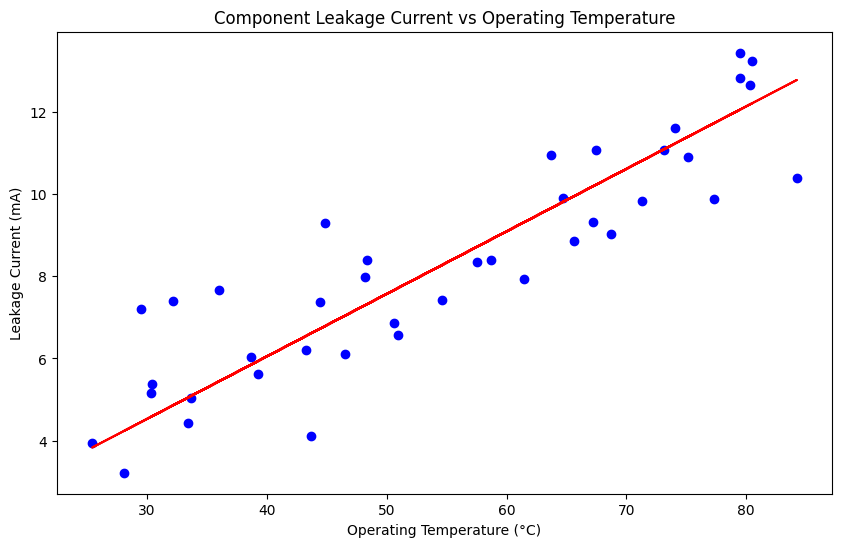

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, predictions, color='red')
plt.xlabel('Operating Temperature (°C)')
plt.ylabel('Leakage Current (mA)')
plt.title('Component Leakage Current vs Operating Temperature')
plt.show()


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)
samples = 300

group1 = np.random.normal(loc=[30, 20], scale=[5, 5], size=(100, 2))
group2 = np.random.normal(loc=[70, 80], scale=[8, 8], size=(100, 2))
group3 = np.random.normal(loc=[50, 50], scale=[6, 6], size=(100, 2))

data = np.vstack([group1, group2, group3])
df = pd.DataFrame(data, columns=['Income_K', 'Spending_Score'])
df.head()


,Income_K,Spending_Score
0,32.483571,19.308678
1,33.238443,27.615149
2,28.829233,18.829315
3,37.896064,23.837174
4,27.652628,22.712800


In [19]:
X = df[['Income_K', 'Spending_Score']]

model = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = model.fit_predict(X)


In [17]:
centroids = model.cluster_centers_
print("Cluster Centers (Income vs Spending):")
print(centroids)


Cluster Centers (Income vs Spending):
[[71.29827392 80.43419415]
 [29.42217873 20.17011162]
 [49.67373692 49.46575534]]


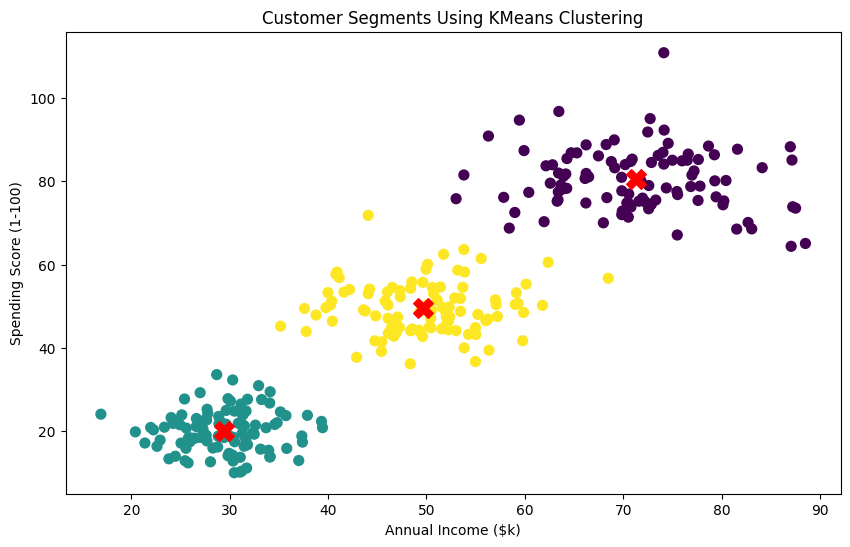

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Income_K'], df['Spending_Score'], c=df['Cluster'], cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')

plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments Using KMeans Clustering')
plt.show()
